# 서울 30년(1995–2025) 일별 기온 시계열 분석

**목적**: 서울의 기온이 30년 동안 어떻게 변했는지 — 추세(trend), 계절성(seasonality), 노이즈/변동성(noise) — 를 데이터로 확인한다.

**실행 순서**: 위에서부터 차례로 모든 셀을 실행한다 (`Run All`). 데이터 파일이 없으면 첫 셀에서 자동으로 내려받는다.
그래프는 `images/` 폴더에 PNG로 저장되고, 결과 해석은 `REPORT.md`에 정리되어 있다.

In [1]:
# ── 0. 준비: 라이브러리, 한글 폰트, 색상, 공통 스타일 ──────────────────────
import subprocess, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from statsmodels.tsa.seasonal import STL

ROOT = Path.cwd()
DATA = ROOT / "data" / "seoul_weather_1995_2025.csv"
IMG = ROOT / "images"
IMG.mkdir(exist_ok=True)

# 한글 폰트 (macOS: AppleGothic / Windows: Malgun Gothic)
plt.rcParams["font.family"] = ["AppleGothic", "Malgun Gothic", "NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

# 색상 (색각이상자도 구분 가능한 검증된 팔레트)
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#9a9893", "#e6e5e0"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlelocation": "left", "font.size": 10, "savefig.dpi": 150, "savefig.bbox": "tight",
})

def style(ax):
    """불필요한 테두리를 지우고 옅은 가로 격자만 남긴다."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    return ax

def save(fig, name):
    fig.savefig(IMG / name)
    print("saved:", IMG / name)

## 1. 데이터 불러오기

In [2]:
if not DATA.exists():   # 데이터가 없으면 수집 스크립트 실행
    subprocess.run([sys.executable, "data/fetch_data.py"], check=True)

df = pd.read_csv(DATA, parse_dates=["date"]).set_index("date").sort_index()
print("행 수(데이터 포인트):", len(df))
print("기간:", df.index.min().date(), "~", df.index.max().date())
print("컬럼:", list(df.columns))
df.head()

행 수(데이터 포인트): 11323
기간: 1995-01-01 ~ 2025-12-31
컬럼: ['temp_mean', 'temp_max', 'temp_min', 'precip']


,temp_mean,temp_max,temp_min,precip
date,,,,
1995-01-01,-3.5,1.1,-6.8,0.0
1995-01-02,-2.2,2.6,-7.8,0.0
1995-01-03,0.1,2.3,-2.1,2.3
1995-01-04,-1.2,2.0,-4.1,0.3
1995-01-05,-2.6,1.4,-4.8,0.3


In [3]:
df.describe().round(1)

,temp_mean,temp_max,temp_min,precip
count,11323.0,11323.0,11323.0,11323.0
mean,11.7,16.5,7.5,3.4
std,10.4,10.3,10.7,10.6
min,-20.2,-14.9,-24.3,0.0
25%,2.5,7.6,-2.1,0.0
50%,12.8,18.0,7.8,0.0
75%,21.2,25.6,17.3,1.2
max,32.8,38.5,28.2,172.1


## 2. 데이터 품질 점검 (결측치 · 중복 · 날짜 누락 · 값의 논리 오류)

시계열은 **날짜가 빠짐없이 순서대로** 있어야 이동평균·변화율 계산이 올바르다. 그래서 값뿐 아니라 날짜 자체도 점검한다.

In [4]:
full_range = pd.date_range(df.index.min(), df.index.max(), freq="D")
checks = {
    "결측치(NaN) 개수": int(df.isna().sum().sum()),
    "중복 날짜 수": int(df.index.duplicated().sum()),
    "빠진 날짜 수": len(full_range.difference(df.index)),
    "물리적 범위(-40~45℃) 벗어난 값": int(((df[["temp_mean","temp_max","temp_min"]] < -40) |
                                          (df[["temp_mean","temp_max","temp_min"]] > 45)).sum().sum()),
    "최저 > 평균 또는 평균 > 최고 인 날": int(((df.temp_min > df.temp_mean) | (df.temp_mean > df.temp_max)).sum()),
    "음수 강수량": int((df.precip < 0).sum()),
}
pd.Series(checks, name="개수").to_frame()

,개수
결측치(NaN) 개수,0
중복 날짜 수,0
빠진 날짜 수,0
물리적 범위(-40~45℃) 벗어난 값,0
최저 > 평균 또는 평균 > 최고 인 날,0
음수 강수량,0


### 이상치(outlier) 기준

기온은 계절에 따라 원래 크게 변하므로 "전체 평균에서 멀다"는 기준은 쓸 수 없다 (1월의 -15℃는 정상이다).
대신 **"그 날짜의 평년 기온에서 얼마나 벗어났나(편차, anomaly)"** 를 보고, 그 날짜 편차의 표준편차 대비 **±3배(|z| > 3)** 를 벗어나면 이상치로 표시한다.

In [5]:
t = df["temp_mean"]
doy = df.index.dayofyear

def circular_smooth(s, window=15):
    """1~366일 값을 원형(12월 말 ↔ 1월 초 연결)으로 이어 붙여 이동평균."""
    ext = pd.concat([s.iloc[-window:], s, s.iloc[:window]])
    return ext.rolling(window, center=True).mean().iloc[window:-window]

clim = circular_smooth(t.groupby(doy).mean())           # 날짜별 평년값
df["anom"] = t - clim.reindex(doy).values                # 편차 = 실제 - 평년
anom_sd = circular_smooth(df["anom"].groupby(doy).std())
df["z"] = df["anom"] / anom_sd.reindex(doy).values

outliers = df.loc[df["z"].abs() > 3, ["temp_mean", "anom", "z"]]
print(f"|z|>3 인 날: {len(outliers)}일 / {len(df)}일 ({len(outliers)/len(df):.2%})")
outliers.round(1).sort_values("z")

|z|>3 인 날: 46일 / 11323일 (0.41%)


,temp_mean,anom,z
date,,,
2013-02-08,-16.9,-15.2,-4.3
2001-01-15,-20.2,-17.1,-4.2
2002-06-24,16.2,-6.5,-4.1
2001-01-14,-19.7,-16.5,-4.1
2013-01-03,-17.0,-13.8,-3.6
2021-10-17,4.4,-9.3,-3.6
2004-01-22,-16.7,-13.7,-3.4
2004-03-06,-6.5,-9.5,-3.3
2018-01-26,-15.9,-13.0,-3.3


**처리 결정: 제거하지 않고 유지한다.**
위 날짜들은 측정 오류가 아니라 실제 한파/이상고온일 가능성이 높고(논리 오류 점검은 모두 0건), 기온 분석에서는 이런 극단값이 오히려 핵심 정보다.
따라서 삭제·대체 없이 그대로 두고, 이동평균처럼 극단값에 덜 민감한 기법으로 추세를 본다.

## 3. 이동평균 — 노이즈를 걷어내고 계절성과 추세 보기

- **30일 이동평균**: 하루하루의 들쭉날쭉(노이즈)을 지우면 **계절 사이클**이 보인다.
- **365일 이동평균**: 1년 치를 평균하면 계절성까지 사라지고 **장기 추세**만 남는다.

365일 이동평균은 변화 폭이 1~2℃ 정도로 작아서, 일별 기온(-20~33℃)과 같은 축에 그리면 평평하게 보인다. 그래서 **아래 패널에 확대된 축으로 따로** 그린다.

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


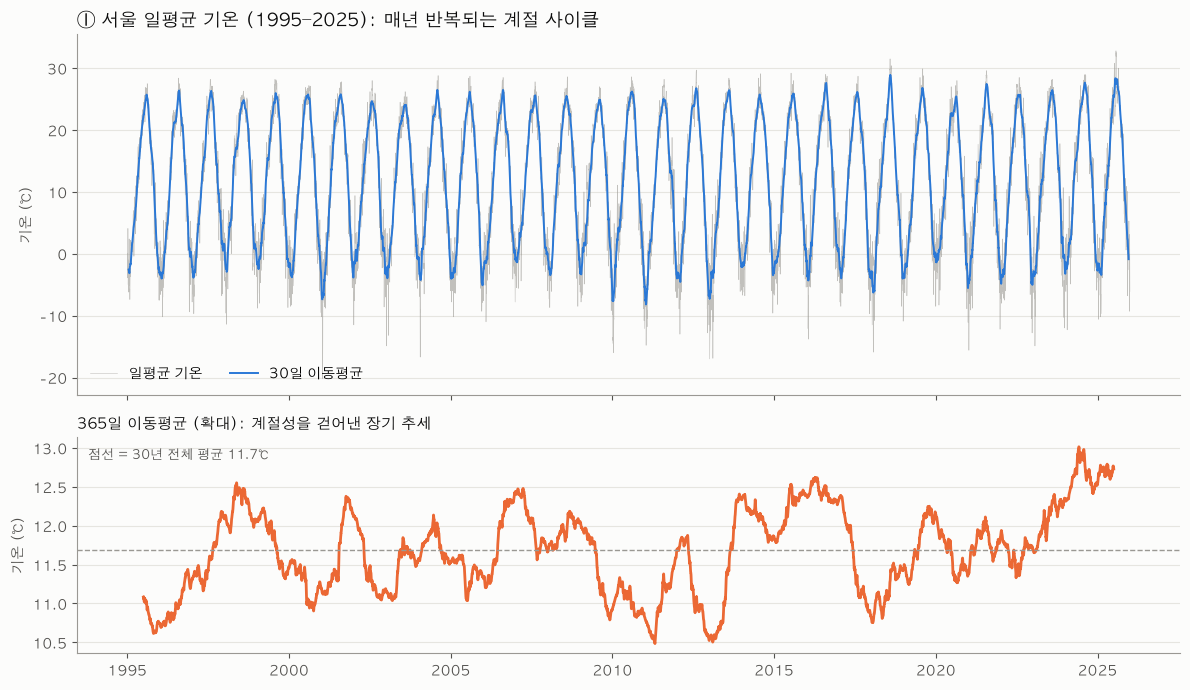

In [6]:
df["ma30"] = t.rolling(30, center=True).mean()
df["ma365"] = t.rolling(365, center=True).mean()

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1.2]})
a1.plot(df.index, t, color=MUTED, lw=0.4, alpha=0.6, label="일평균 기온")
a1.plot(df.index, df.ma30, color=BLUE, lw=1.4, label="30일 이동평균")
a1.set_title("① 서울 일평균 기온 (1995–2025): 매년 반복되는 계절 사이클")
a1.set_ylabel("기온 (℃)")
a1.legend(loc="lower left", frameon=False, ncol=2)
style(a1)

a2.plot(df.index, df.ma365, color=ORANGE, lw=2)
a2.axhline(t.mean(), color=MUTED, lw=1, ls="--")
a2.text(0.01, 0.95, f"점선 = 30년 전체 평균 {t.mean():.1f}℃", transform=a2.transAxes, va="top", color=INK2, fontsize=9)
a2.set_title("365일 이동평균 (확대): 계절성을 걷어낸 장기 추세", fontsize=11)
a2.set_ylabel("기온 (℃)")
a2.xaxis.set_major_locator(mdates.YearLocator(5))
a2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
style(a2)
fig.tight_layout()
save(fig, "01_daily_moving_average.png")

## 4. 연평균 기온 추세 — 정말 따뜻해졌나?

**구간별 통계 + 선형회귀**: 연평균 기온에 직선을 맞춰 기울기(10년당 몇 ℃)를 구하고, p-value로 "우연히 이 정도 기울기가 나올 확률"을 확인한다.

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


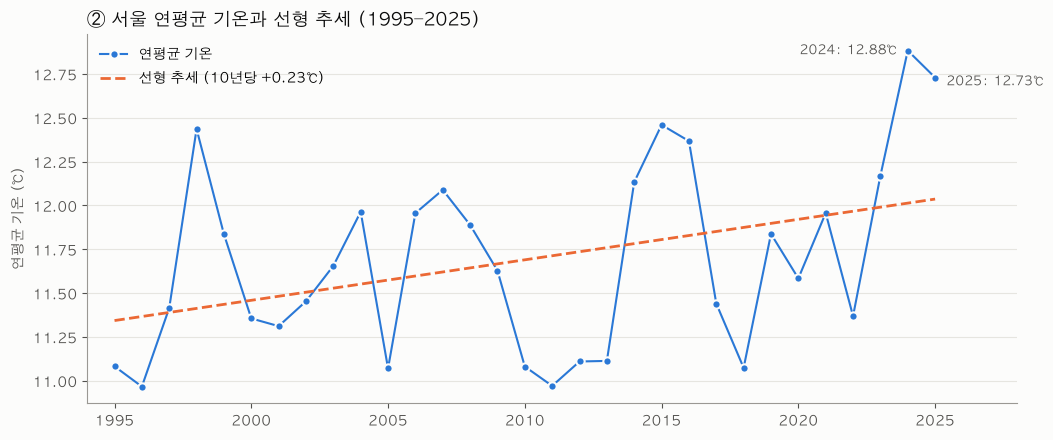

In [7]:
annual = t.groupby(df.index.year).mean()
res = stats.linregress(annual.index, annual.values)
print(f"선형 추세: 10년당 {res.slope*10:+.2f}℃  (p-value = {res.pvalue:.3f}, R² = {res.rvalue**2:.2f})")
print(f"추세선 기준 30년간 변화: {res.slope*30:+.2f}℃")

decade = pd.cut(annual.index, [1994, 2004, 2014, 2025], labels=["1995–2004", "2005–2014", "2015–2025"])
print("\n구간별 연평균 기온:")
print(annual.groupby(decade, observed=True).agg(["mean", "min", "max"]).round(2))
print("\n가장 더운 해 Top 5:\n", annual.sort_values(ascending=False).head().round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(annual.index, annual.values, color=BLUE, lw=1.5, marker="o", ms=6,
        markeredgecolor="#fcfcfb", markeredgewidth=1.5, label="연평균 기온")
ax.plot(annual.index, res.intercept + res.slope * annual.index, color=ORANGE, lw=2, ls="--",
        label=f"선형 추세 (10년당 {res.slope*10:+.2f}℃)")
for y, off in [(2024, (-78, 0)), (2025, (8, -3))]:
    ax.annotate(f"{y}: {annual[y]:.2f}℃", (y, annual[y]), textcoords="offset points",
                xytext=off, color=INK2, fontsize=9, va="center")
ax.set_xlim(1994, 2028)
ax.set_title("② 서울 연평균 기온과 선형 추세 (1995–2025)")
ax.set_ylabel("연평균 기온 (℃)")
ax.legend(frameon=False, loc="upper left")
style(ax)
save(fig, "02_annual_trend.png")

## 5. 계절성 — 어느 계절이 가장 많이 변했나?

**월별 집계**: 초기 10년(1995–2004)과 최근 10년(2016–2025)의 월평균 기온을 비교한다.
두 값의 **차이**는 크기가 작아(±2℃ 내외) 원래 기온 축에서는 안 보이므로 아래 패널에 따로 그린다.

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


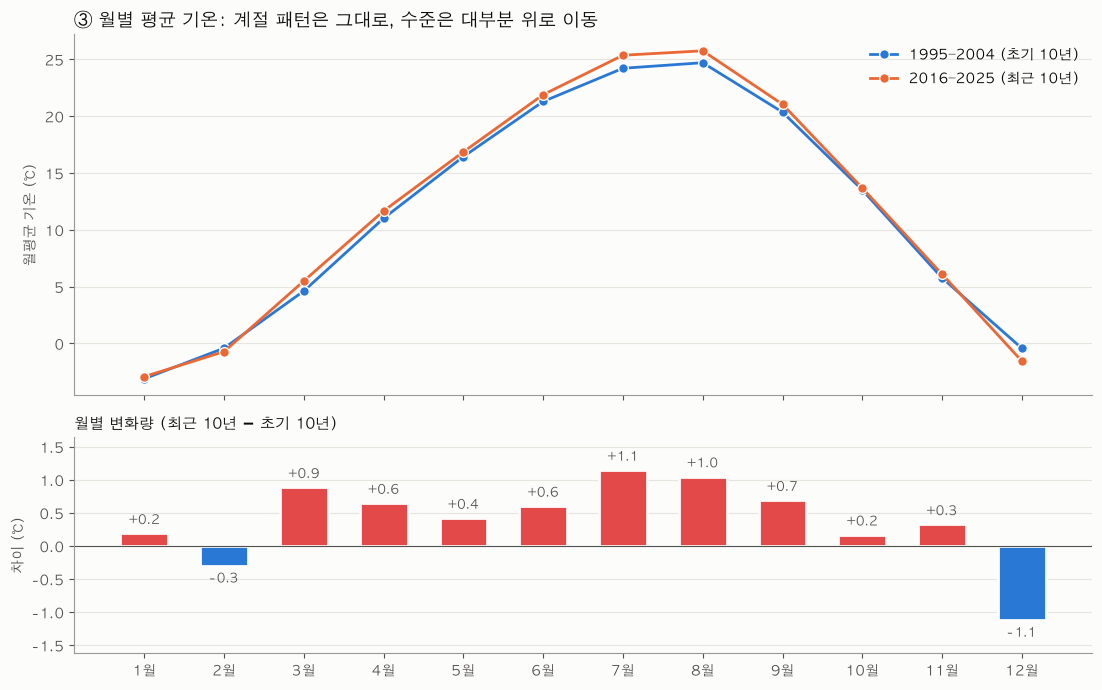

In [8]:
m = df.index.month
early = t[(df.index.year <= 2004)].groupby(m[df.index.year <= 2004]).mean()
late  = t[(df.index.year >= 2016)].groupby(m[df.index.year >= 2016]).mean()
diff = (late - early)
print("월별 변화(최근10년 - 초기10년, ℃):")
print(diff.round(2).to_string())
season = {12:"겨울",1:"겨울",2:"겨울",3:"봄",4:"봄",5:"봄",6:"여름",7:"여름",8:"여름",9:"가을",10:"가을",11:"가을"}
print("\n계절별 평균 변화:\n", diff.groupby(diff.index.map(season)).mean().round(2).to_string())

months = [f"{i}월" for i in range(1, 13)]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1.2]})
a1.plot(months, early.values, color=BLUE, lw=2, marker="o", ms=7, markeredgecolor="#fcfcfb", label="1995–2004 (초기 10년)")
a1.plot(months, late.values, color=ORANGE, lw=2, marker="o", ms=7, markeredgecolor="#fcfcfb", label="2016–2025 (최근 10년)")
a1.set_title("③ 월별 평균 기온: 계절 패턴은 그대로, 수준은 대부분 위로 이동")
a1.set_ylabel("월평균 기온 (℃)")
a1.legend(frameon=False)
style(a1)
colors = [RED if v > 0 else BLUE for v in diff.values]
a2.bar(months, diff.values, color=colors, width=0.6, edgecolor="#fcfcfb", linewidth=2)
a2.axhline(0, color=INK2, lw=0.8)
for i, v in enumerate(diff.values):
    a2.text(i, v + (0.08 if v >= 0 else -0.08), f"{v:+.1f}", ha="center",
            va="bottom" if v >= 0 else "top", fontsize=9, color=INK2)
a2.set_title("월별 변화량 (최근 10년 − 초기 10년)", fontsize=11)
a2.set_ylabel("차이 (℃)")
a2.set_ylim(diff.min() - 0.5, diff.max() + 0.5)
style(a2)
fig.tight_layout()
save(fig, "03_monthly_seasonality.png")

### 이 차이는 우연일 수도 있을까? (검증)

10년 평균끼리 비교하면 한두 해의 극단값에 흔들릴 수 있다. 그래서 각 해의 계절 평균을 한 표본으로 보고
초기 10년 vs 최근 10년을 **Welch t-검정**으로 비교한다. p-value < 0.05 이면 "우연으로 보기 어렵다"고 판단한다.

In [9]:
mm = t.resample("MS").mean()
rows = {}
for name, ms in {"여름(6–8월)": (6, 7, 8), "7–8월": (7, 8), "3월": (3,), "12월": (12,), "겨울(12–2월)": (12, 1, 2)}.items():
    s = mm[mm.index.month.isin(ms)]
    s = s.groupby(s.index.year).mean()
    e, l = s.loc[1995:2004], s.loc[2016:2025]
    rows[name] = {"차이(℃)": l.mean() - e.mean(), "p-value": stats.ttest_ind(l, e, equal_var=False).pvalue,
                  "해마다 흔들림(표준편차) 초기": e.std(), "최근": l.std()}
pd.DataFrame(rows).T.round(3)

,차이(℃),p-value,해마다 흔들림(표준편차) 초기,최근
여름(6–8월),0.932,0.007,0.542,0.782
7–8월,1.096,0.008,0.561,0.976
3월,0.885,0.031,0.814,0.876
12월,-1.125,0.077,1.000,1.585
겨울(12–2월),-0.422,0.408,1.124,1.099


### 연도 × 월 편차 히트맵

같은 달끼리 비교해야 공정하다 (1월과 8월을 직접 비교하면 계절 차이만 보인다).
그래서 각 칸 = **그 해 그 달의 평균 − 1995–2024년(30년) 같은 달 평균**. 빨강 = 평년보다 더움, 파랑 = 평년보다 추움.

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


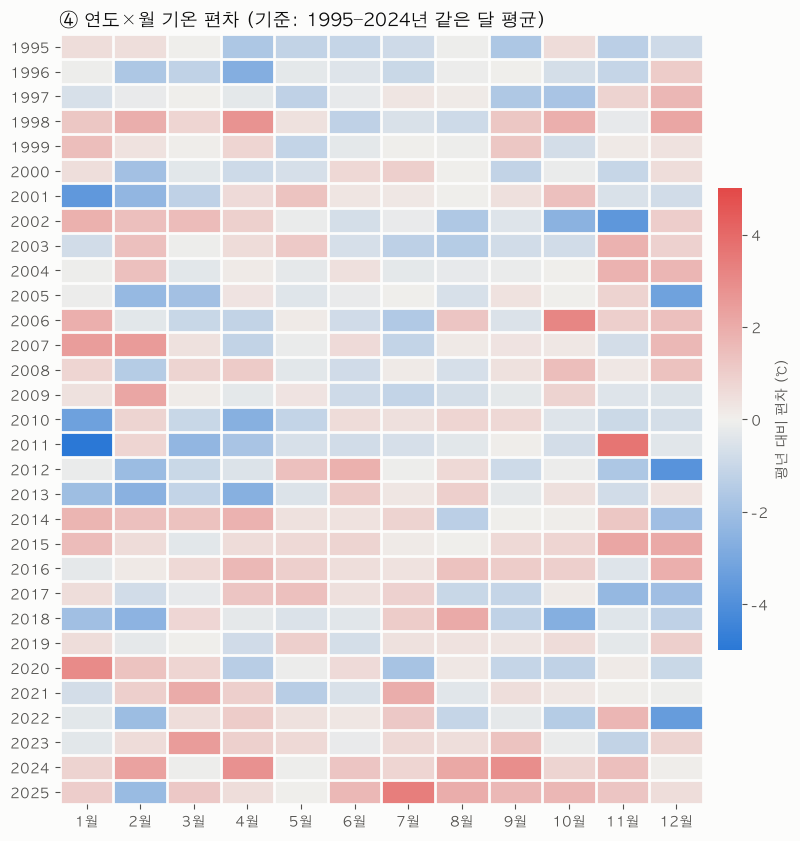

In [10]:
monthly = t.resample("MS").mean()
base = monthly[monthly.index.year <= 2024]
normal = base.groupby(base.index.month).mean()          # 30년 월별 평년값
mon_anom = monthly - normal.reindex(monthly.index.month).values
grid = mon_anom.to_frame("a").assign(y=mon_anom.index.year, m=mon_anom.index.month).pivot(index="y", columns="m", values="a")

cmap = LinearSegmentedColormap.from_list("div", [BLUE, "#f0efec", RED])
lim = np.ceil(np.abs(grid.values).max())
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(grid.values, cmap=cmap, vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(12), months)
ax.set_yticks(range(len(grid)), grid.index)
ax.set_xticks(np.arange(-.5, 12, 1), minor=True); ax.set_yticks(np.arange(-.5, len(grid), 1), minor=True)
ax.grid(which="minor", color="#fcfcfb", linewidth=2); ax.tick_params(which="minor", length=0)
for s in ax.spines.values(): s.set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02); cb.set_label("평년 대비 편차 (℃)", color=INK2); cb.outline.set_visible(False)
ax.set_title("④ 연도×월 기온 편차 (기준: 1995–2024년 같은 달 평균)")
save(fig, "04_anomaly_heatmap.png")

print("편차가 가장 큰 달 Top 5 (더움):")
print(mon_anom.sort_values(ascending=False).head().round(2).to_string())
print("\n편차가 가장 큰 달 Top 5 (추움):")
print(mon_anom.sort_values().head().round(2).to_string())
share_warm = (mon_anom[mon_anom.index.year >= 2021] > 0).mean()
print(f"\n2021–2025년 60개월 중 평년보다 따뜻했던 달의 비율: {share_warm:.0%}")

## 6. 극한 기온 — 폭염일과 열대야

평균만 보면 극단적인 날의 변화를 놓칠 수 있다. 기상청 기준을 빌려 연도별로 센다.
- **폭염일**: 일 최고기온 ≥ 33℃
- **열대야**: 일 최저기온 ≥ 25℃ (원래 기준은 '밤 최저', 여기서는 일 최저기온으로 근사)

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


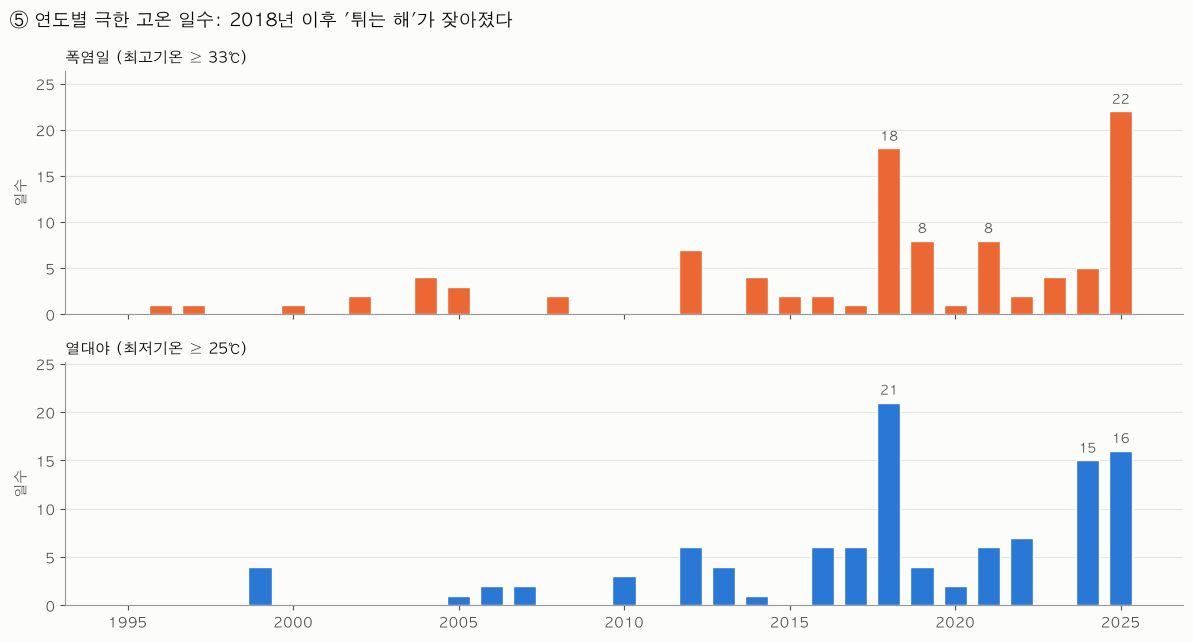

In [11]:
yr = df.index.year
hot = (df.temp_max >= 33).groupby(yr).sum()
trop = (df.temp_min >= 25).groupby(yr).sum()
ext = pd.DataFrame({"폭염일": hot, "열대야": trop})
per = pd.cut(ext.index, [1994, 2004, 2014, 2025], labels=["1995–2004", "2005–2014", "2015–2025"])
print("구간별 합계 (일):"); print(ext.groupby(per, observed=True).sum())
print("\n폭염일 많은 해 Top 5:\n", hot.sort_values(ascending=False).head().to_string())
print("\n2018년 연평균 기온 순위:", int(annual.rank(ascending=False)[2018]), "위 /", len(annual), "년")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
for ax, s, c, title in [(a1, hot, ORANGE, "폭염일 (최고기온 ≥ 33℃)"), (a2, trop, BLUE, "열대야 (최저기온 ≥ 25℃)")]:
    ax.bar(s.index, s.values, color=c, width=0.7, edgecolor="#fcfcfb", linewidth=1)
    for y in s[s >= s.max() * 0.35].index:   # 눈에 띄는 해만 숫자 표시
        ax.text(y, s[y] + 0.4, f"{s[y]}", ha="center", va="bottom", fontsize=9, color=INK2)
    ax.set_ylabel("일수")
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, s.max() * 1.2)
    style(ax)
fig.suptitle("⑤ 연도별 극한 고온 일수: 2018년 이후 '튀는 해'가 잦아졌다", x=0.01, ha="left",
             fontsize=13, fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "05_extreme_heat_days.png")

## 7. 변화율과 변동성 — 어느 달의 날씨가 가장 '들쭉날쭉'한가?

- **변화율(일간 변화량)**: 오늘 기온 − 어제 기온. 기온은 0℃를 지나므로 %가 아닌 **℃ 차이**를 변화율로 쓴다.
- **변동성**: 일간 변화량의 **표준편차**. 클수록 하루 사이 기온이 크게 바뀐다.

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


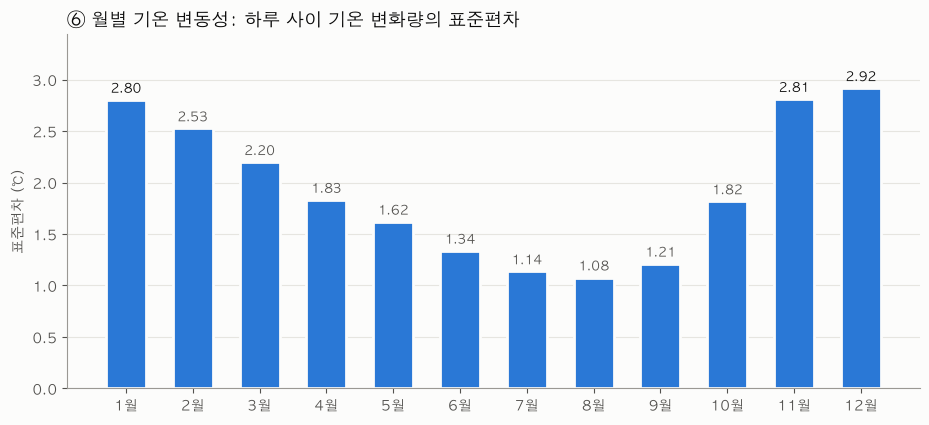

In [12]:
df["chg"] = t.diff()
vol = df.groupby(df.index.month)["chg"].std()
big = df["chg"].abs() >= 5
print("월별 일간 변화량 표준편차(℃):"); print(vol.round(2).to_string())
print(f"\n하루 새 5℃ 이상 변한 날: {big.sum()}일 ({big.mean():.1%})")
print("그 중 월별 분포(%):"); print((df[big].index.month.value_counts(normalize=True).sort_index()*100).round(1).to_string())
print("\n가장 크게 떨어진 날:"); print(df["chg"].nsmallest(3).round(1).to_string())

# 연대별 변동성이 달라졌는지도 확인
day_per = pd.cut(df.index.year, [1994, 2004, 2014, 2025], labels=["1995–2004", "2005–2014", "2015–2025"])
vol_dec = df.groupby(day_per, observed=True)["chg"].std()
print("\n구간별 일간 변화량 표준편차:"); print(vol_dec.round(2).to_string())

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.bar(months, vol.values, color=BLUE, width=0.6, edgecolor="#fcfcfb", linewidth=2)
top = vol.nlargest(3).index
for i, v in enumerate(vol.values):
    ax.text(i, v + 0.03, f"{v:.2f}", ha="center", va="bottom", fontsize=9,
            color=INK if (i + 1) in top else INK2, fontweight="bold" if (i + 1) in top else "normal")
ax.set_title("⑥ 월별 기온 변동성: 하루 사이 기온 변화량의 표준편차")
ax.set_ylabel("표준편차 (℃)")
ax.set_ylim(0, vol.max() * 1.18)
style(ax)
save(fig, "06_volatility_by_month.png")

## 8. [보너스 A] 시계열 분해 (STL)

월평균 기온을 **추세(Trend) + 계절성(Seasonal) + 잔차(Residual/노이즈)** 세 부분으로 분리한다.
STL은 '계절 성분은 매년 비슷하게 반복된다'는 가정으로 12개월 주기를 뽑아내고, 남은 것 중 천천히 움직이는 부분을 추세로, 나머지를 잔차로 본다.

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


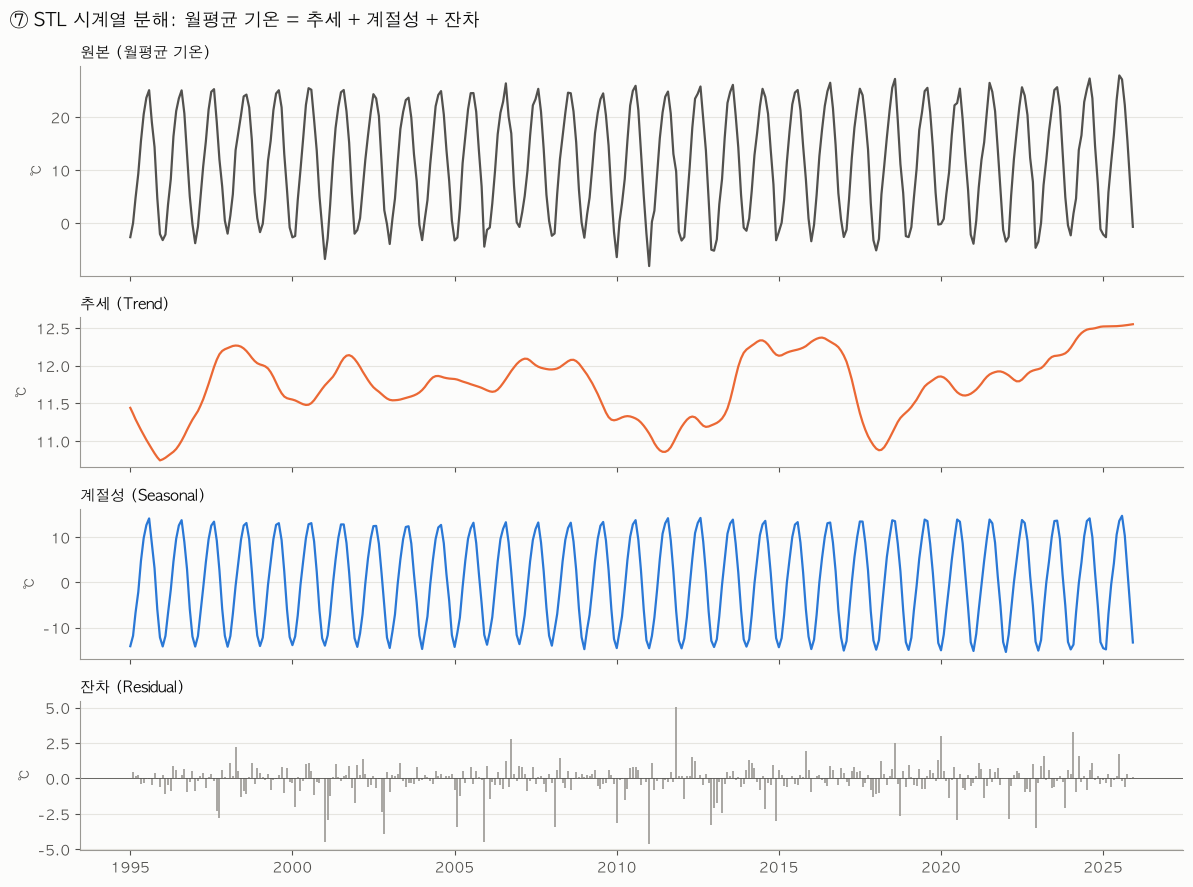

In [13]:
stl = STL(monthly, period=12, robust=True).fit()
comp = pd.DataFrame({"trend": stl.trend, "seasonal": stl.seasonal, "resid": stl.resid})
tr_y = comp.trend.groupby(comp.index.year).mean()
print(f"추세 성분: {tr_y.iloc[0]:.2f}℃ (1995) → {tr_y.iloc[-1]:.2f}℃ (2025), 변화 {tr_y.iloc[-1]-tr_y.iloc[0]:+.2f}℃")
print(f"계절 성분 진폭(최고-최저): {comp.seasonal.max()-comp.seasonal.min():.1f}℃")
print(f"잔차 표준편차: {comp.resid.std():.2f}℃")
var_share = {k: comp[k].var() / monthly.var() for k in comp}
print("분산 비율(대략):", {k: f"{v:.1%}" for k, v in var_share.items()})
print("\n잔차가 가장 큰 달:"); print(comp.resid.abs().nlargest(5).round(2).to_string())

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True, gridspec_kw={"height_ratios": [1.4, 1, 1, 1]})
spec = [(monthly, "원본 (월평균 기온)", INK2), (comp.trend, "추세 (Trend)", ORANGE),
        (comp.seasonal, "계절성 (Seasonal)", BLUE), (comp.resid, "잔차 (Residual)", MUTED)]
for ax, (s, name, c) in zip(axes, spec):
    if name.startswith("잔차"):
        ax.vlines(s.index, 0, s.values, color=c, lw=1.2); ax.axhline(0, color=INK2, lw=0.6)
    else:
        ax.plot(s.index, s.values, color=c, lw=1.6)
    ax.set_ylabel("℃"); ax.set_title(name, fontsize=11); style(ax)
axes[-1].xaxis.set_major_locator(mdates.YearLocator(5)); axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("⑦ STL 시계열 분해: 월평균 기온 = 추세 + 계절성 + 잔차", x=0.01, ha="left", fontsize=13, fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "07_stl_decomposition.png")

## 9. [보너스 B] 베이스라인 예측 — 2025년을 맞혀 보기

1995–2024년만 보고 2025년 일평균 기온을 예측한 뒤, 실제 2025년과 비교한다. 복잡한 모델이 아니라 **"이 정도는 누구나 할 수 있다"는 기준선(베이스라인)** 세 가지:

| 방법 | 가정 |
|---|---|
| (1) 작년 같은 날 | 올해는 작년과 똑같을 것이다 |
| (2) 30년 평년값 | 올해는 지난 30년 평균과 같을 것이다 |
| (3) 최근 10년 평년값 | 기후가 변하고 있으니 최근 10년 평균이 더 맞을 것이다 |

평가 지표: **MAE(평균 절대 오차)** = 예측과 실제의 차이(절댓값)의 평균. 작을수록 좋다. **Bias(편향)** = (예측 − 실제)의 평균. 음수면 체계적으로 낮게 예측한 것.

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


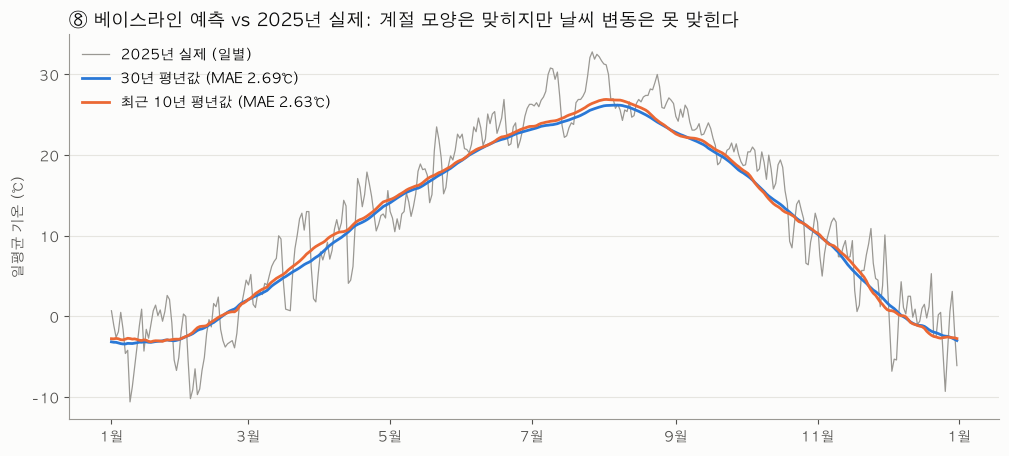

In [14]:
train = t[t.index.year <= 2024]
test = t[t.index.year == 2025]
tdoy = test.index.dayofyear

def doy_clim(s):
    return circular_smooth(s.groupby(s.index.dayofyear).mean())

preds = pd.DataFrame({
    "실제": test,
    "(1) 작년 같은 날": train.reindex(test.index - pd.DateOffset(years=1)).values,
    "(2) 30년 평년값": doy_clim(train).reindex(tdoy).values,
    "(3) 최근 10년 평년값": doy_clim(train[train.index.year >= 2015]).reindex(tdoy).values,
}, index=test.index)

score = pd.DataFrame({
    "MAE(℃)": {c: (preds[c] - preds["실제"]).abs().mean() for c in preds.columns[1:]},
    "Bias(℃)": {c: (preds[c] - preds["실제"]).mean() for c in preds.columns[1:]},
}).round(2)
print(score)
print("\n월별 MAE (30년 평년값 기준):")
print((preds["(2) 30년 평년값"] - preds["실제"]).abs().groupby(test.index.month).mean().round(1).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(preds.index, preds["실제"], color=MUTED, lw=0.9, label="2025년 실제 (일별)")
ax.plot(preds.index, preds["(2) 30년 평년값"], color=BLUE, lw=2, label=f"30년 평년값 (MAE {score.loc['(2) 30년 평년값','MAE(℃)']}℃)")
ax.plot(preds.index, preds["(3) 최근 10년 평년값"], color=ORANGE, lw=2, label=f"최근 10년 평년값 (MAE {score.loc['(3) 최근 10년 평년값','MAE(℃)']}℃)")
ax.set_title("⑧ 베이스라인 예측 vs 2025년 실제: 계절 모양은 맞히지만 날씨 변동은 못 맞힌다")
ax.set_ylabel("일평균 기온 (℃)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%-m월"))
ax.legend(frameon=False, loc="upper left")
style(ax)
save(fig, "08_baseline_forecast.png")

## 10. 정리

분석 결과의 해석(관찰 vs 가설), 인사이트, 한계점은 **`REPORT.md`** 에 정리했다.